# Cosmatic Chemical 
---

Group Name

Team members:
- Husna Alderazi
- Mariam Isa

## Introduction 
__Introduction to the topic__ 

The data is from the California Safe Cosmetics Program (CSCP) in the California Department of Public Health. The primary purpose of the CSCP is to collect information on hazardous and potentially hazardous ingredients in cosmetic products sold in California and to make this information available to the public.
Many different chemicals are used in making cosmetics. Consumer and worker advocacy groups are concerned because some cosmetic products contain chemicals known or suspected to cause cancer, birth defects, or damage to the reproductive system. Those who work with cosmetics — including barbers, hair stylists, and skin care, body care and nail salon workers — may be more vulnerable to the adverse health effects posed by these products.

---

## Problem Statement

This study aims to analyze the speed of reporting the hazardous chemical in cosmatic products and removal them from the market or refomilating the product under the California Safe Cosmetics Act and monitored by the California Department of Public Health.

## Objectives:
__Questions that will guide the analysis to solve the problem__

1. Which primary product categories contain the highest diversity of chemicals?
2. Which chemicals appear most frequently across cosmetic products?
3. Which companies/brands use the widest variety of chemicals?
4. How has the reporting of chemicals changed over time?
5. How have the number of reported chemicals, removed chemicals, and discontinued products changed over the years?
6. How long after product registration are hazardous chemicals reported?
7. What is the typical time lag between chemical reporting and removal (reformulation)?
8. Which categories respond faster?
9. Which chemicals stay the longest?
10. Do complex products take longer to fix?
11. Is industry getting faster over time?

---

## Exploratory Data Analysis (EDA):

### Data Dictionary 

| Field                  | Type      | Description                                                                                                                                                                                                                                                                      |
|------------------------|-----------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| _id                    | int       |                                                                                                                                                                                                                                                                                  |
| CDPHId                 | text      | The California Department of Public Health (CDPH) internal identification number for product. Note that the CDPHId may appear more than once if a product has more than one Color/Scent/Flavor, more than one Category, or more than one Chemical Name/CAS number reported.       |
| ProductName            | text      | Product name as entered by manufacturer, packer and/or distributor. The product name is entered as free-text into the reporting database and may contain misspellings or other errors.                                                                                            |
| CSFId                  | text      | CDPH internal identification number for a color/scent/flavor.                                                                                                                                                                                                                    |
| CSF                    | text      | Color, scent and/or flavor as entered by manufacturer, packer and/or distributor. Not all products have specific colors, scents or flavors.                                                                                                                                       |
| CompanyId              | text      | CDPH internal identification number for company.                                                                                                                                                                                                                                 |
| CompanyName            | text      | Company name as entered by manufacturer, packer and/or distributor. May contain misspellings or other errors.                                                                                                                                                                    |
| BrandName              | text      | Brand name as entered by manufacturer, packer and/or distributor. May contain misspellings or other errors.                                                                                                                                                                      |
| PrimaryCategoryId      | text      | CDPH internal identification number for category.                                                                                                                                                                                                                                |
| PrimaryCategory        | text      | Type of product (13 primary categories: Baby Products, Bath Products, Fragrances, Hair Care Products, Hair Coloring Products, Makeup Products, Nail Products, Oral Hygiene Products, Personal Care Products, Shaving Products, Skin Care Products, Sun-Related Products, Tattoos).|
| SubCategoryId          | text      | CDPH internal identification number for subcategory.                                                                                                                                                                                                                             |
| SubCategory            | text      | Type of product within one of the 13 primary categories.                                                                                                                                                                                                                         |
| CasId                  | text      | CDPH internal identification number for chemical.                                                                                                                                                                                                                                |
| CasNumber              | text      | Chemical identification number (Chemical Abstracts Service registry number). Note that different forms of a chemical may have different CAS numbers.                                                                                                                              |
| ChemicalId             | text      | CDPH internal identification number for this chemical's record specific to this product.                                                                                                                                                                                         |
| ChemicalName           | text      | Name of chemical substance in cosmetic product. The California Safe Cosmetics Act requires companies to report products containing ingredients known or suspected to cause cancer or developmental or reproductive harm.                                                           |
| InitialDateReported    | timestamp | Date the product profile was created by manufacturer, packer and/or distributor; the date the product was first reported to CDPH.                                                                                                                                                |
| MostRecentDateReported | timestamp | Date the product profile was last modified by manufacturer, packer and/or distributor. Defaults to InitialDateReported value initially.                                                                                                                                           |
| DiscontinuedDate       | timestamp | If applicable, date the product was discontinued.                                                                                                                                                                                                                                |
| ChemicalCreatedAt      | timestamp | The date that this chemical was first reported to CDPH for this product.                                                                                                                                                                                                         |
| ChemicalUpdatedAt      | timestamp | Date this chemical report was last modified by manufacturer, packer and/or distributor. Defaults to ChemicalCreatedAt value initially.                                                                                                                                           |
| ChemicalDateRemoved    | timestamp | If applicable, date the chemical was removed from the product (i.e., reformulation).                                                                                                                                                                                             |
| ChemicalCount          | numeric   | Total number of current chemicals reported for this product. Does not include removed chemicals. This is a calculated field based on current reporting.                                                                                                                           |

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('./data/cosmetic-chemicals.csv')

In [3]:
data.head()

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),07/01/2009,07/01/2009,NaN,07/01/2009,07/01/2009,NaN,2
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,07/01/2009,07/01/2009,NaN,07/02/2009,07/02/2009,NaN,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,07/09/2009,08/28/2013,NaN,07/09/2009,07/09/2009,NaN,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1


In [4]:
data.shape

(114635, 22)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 114635 entries, 0 to 114634
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CDPHId                  114635 non-null  int64  
 1   ProductName             114635 non-null  str    
 2   CSFId                   80662 non-null   float64
 3   CSF                     80237 non-null   str    
 4   CompanyId               114635 non-null  int64  
 5   CompanyName             114635 non-null  str    
 6   BrandName               114408 non-null  str    
 7   PrimaryCategoryId       114635 non-null  int64  
 8   PrimaryCategory         114635 non-null  str    
 9   SubCategoryId           114635 non-null  int64  
 10  SubCategory             114635 non-null  str    
 11  CasId                   114635 non-null  int64  
 12  CasNumber               108159 non-null  str    
 13  ChemicalId              114635 non-null  int64  
 14  ChemicalName            114635 

In [6]:
data.describe()

,CDPHId,CSFId,CompanyId,PrimaryCategoryId,SubCategoryId,CasId,ChemicalId,ChemicalCount
count,114635.000000,80662.000000,114635.000000,114635.000000,114635.000000,114635.000000,114635.000000,114635.000000
mean,20304.858987,32608.658377,450.641532,51.076294,66.819252,674.094107,32837.556959,1.288359
std,12489.052554,19089.443910,409.533093,20.474341,35.822097,149.214101,20439.412299,0.636418
min,2.000000,1.000000,4.000000,1.000000,3.000000,2.000000,0.000000,0.000000
25%,8717.000000,15789.000000,86.000000,44.000000,48.000000,656.000000,13990.000000,1.000000
50%,20895.000000,32541.000000,297.000000,44.000000,52.000000,656.000000,32055.000000,1.000000
75%,31338.500000,48717.750000,798.000000,59.000000,65.000000,656.000000,51578.500000,1.000000
max,41524.000000,65009.000000,1391.000000,111.000000,172.000000,1242.000000,68074.000000,9.000000


In [7]:
data.columns

Index(['CDPHId', 'ProductName', 'CSFId', 'CSF', 'CompanyId', 'CompanyName',
       'BrandName', 'PrimaryCategoryId', 'PrimaryCategory', 'SubCategoryId',
       'SubCategory', 'CasId', 'CasNumber', 'ChemicalId', 'ChemicalName',
       'InitialDateReported', 'MostRecentDateReported', 'DiscontinuedDate',
       'ChemicalCreatedAt', 'ChemicalUpdatedAt', 'ChemicalDateRemoved',
       'ChemicalCount'],
      dtype='str')

In [8]:
# show how many nulls in each column, sort them descending
data.isnull().sum().sort_values(ascending=False)

ChemicalDateRemoved       111650
DiscontinuedDate          101715
CSF                        34398
CSFId                      33973
CasNumber                   6476
BrandName                    227
CDPHId                         0
ChemicalId                     0
ChemicalUpdatedAt              0
ChemicalCreatedAt              0
MostRecentDateReported         0
InitialDateReported            0
ChemicalName                   0
CasId                          0
ProductName                    0
SubCategory                    0
SubCategoryId                  0
PrimaryCategory                0
PrimaryCategoryId              0
CompanyName                    0
CompanyId                      0
ChemicalCount                  0
dtype: int64

In [9]:
# show the percentage of nulls in each column
data.isnull().mean().sort_values(ascending=False)

ChemicalDateRemoved       0.973961
DiscontinuedDate          0.887294
CSF                       0.300065
CSFId                     0.296358
CasNumber                 0.056492
BrandName                 0.001980
CDPHId                    0.000000
ChemicalId                0.000000
ChemicalUpdatedAt         0.000000
ChemicalCreatedAt         0.000000
MostRecentDateReported    0.000000
InitialDateReported       0.000000
ChemicalName              0.000000
CasId                     0.000000
ProductName               0.000000
SubCategory               0.000000
SubCategoryId             0.000000
PrimaryCategory           0.000000
PrimaryCategoryId         0.000000
CompanyName               0.000000
CompanyId                 0.000000
ChemicalCount             0.000000
dtype: float64

### Data Handling: 
__Cleaning, transforming, and combining data__

In [10]:
#Convert the dates to timestamp type
data['InitialDateReported'] = pd.to_datetime(data['InitialDateReported'])
data['MostRecentDateReported'] = pd.to_datetime(data['MostRecentDateReported'])
data['ChemicalCreatedAt'] = pd.to_datetime(data['ChemicalCreatedAt'])
data['ChemicalUpdatedAt'] = pd.to_datetime(data['ChemicalUpdatedAt'])
data['DiscontinuedDate'] = pd.to_datetime(data['DiscontinuedDate'])
data['ChemicalDateRemoved'] = pd.to_datetime(data['ChemicalDateRemoved'])

In [11]:
data['ChemicalDateRemoved'].max()

Timestamp('2104-05-02 00:00:00')

In [12]:
# 2103 → 2013
data.loc[data['ChemicalDateRemoved'].dt.year == 2103, 'ChemicalDateRemoved'] = data['ChemicalDateRemoved'] - pd.DateOffset(years=90)

# 2104 → 2014
data.loc[data['ChemicalDateRemoved'].dt.year == 2104, 'ChemicalDateRemoved'] = data['ChemicalDateRemoved'] - pd.DateOffset(years=90)

In [13]:
# remove the deplicate rows where having the same 'CDPHId', 'ChemicalName', 'CasNumber' means the recored is duplicated 
data = data.drop_duplicates(subset=['CDPHId', 'ChemicalName', 'CasNumber']) 


In [14]:
#Finding the duration of the following: 

data['InitialDateReported'] = pd.to_datetime(data['InitialDateReported'], errors='coerce')
data['ChemicalCreatedAt'] = pd.to_datetime(data['ChemicalCreatedAt'], errors='coerce')

data['Time_to_Chemical_Report'] = (data['ChemicalCreatedAt'] - data['InitialDateReported']).dt.days #Time takes to detect the chemical 
data['Time_to_discontoued'] = (data['DiscontinuedDate'] - data['InitialDateReported']).dt.days # The total time it hase been in the market 
data['Time_to_Reformulation'] = (data['ChemicalDateRemoved'] - data['ChemicalCreatedAt']).dt.days #Time takes to reformation after the detection

data.head()


#chech the number of the reported without action, what is the trend overtime, is it related to a specific chemical 
#If there is spesific company that get along with 

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,Time_to_Chemical_Report,Time_to_discontoued,Time_to_Reformulation
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,2009-06-17,2013-08-28,2011-02-01,2009-07-09,2009-07-09,NaT,1,22,594.0,NaN
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,2009-07-01,2009-07-01,NaT,2009-07-01,2009-07-01,NaT,2,0,NaN,NaN
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,2009-07-01,2009-07-01,NaT,2009-07-02,2009-07-02,NaT,2,1,NaN,NaN
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,2009-07-09,2013-08-28,NaT,2009-07-09,2009-07-09,NaT,1,0,NaN,NaN
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,2009-07-09,2013-08-28,2011-02-01,2009-07-09,2009-07-09,NaT,1,0,572.0,NaN


In [15]:
data['PrimaryCategory'].value_counts()

PrimaryCategory
Makeup Products (non-permanent)      20648
Nail Products                         8037
Skin Care Products                    5572
Bath Products                         2516
Hair Care Products (non-coloring)     1412
Sun-Related Products                   924
Hair Coloring Products                 816
Fragrances                             478
Personal Care Products                 447
Oral Hygiene Products                  397
Tattoos and Permanent Makeup           373
Shaving Products                       200
Baby Products                           46
Name: count, dtype: int64

In [16]:
data['ChemicalName'].value_counts()

ChemicalName
Titanium dioxide                                                                                       32024
Silica, crystalline (airborne particles of respirable size)                                             1358
Cocamide diethanolamine                                                                                  899
Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.      730
Carbon black                                                                                             718
                                                                                                       ...  
N-Nitrosodiethanolamine                                                                                    1
Vinyl acetate                                                                                              1
Phenacemide                                                                                                1
Dietha

In [17]:
data[data['DiscontinuedDate'] < '2009-01-01']

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,Time_to_Chemical_Report,Time_to_discontoued,Time_to_Reformulation
1680,741,Zest Spring Burst Bar,NaN,NaN,86,The Procter & Gamble Company,Zest,6,Bath Products,159,...,2009-09-11,2017-05-11,2008-08-01,2009-09-11,2009-09-11,NaT,1,0,-406.0,NaN
4528,1318,Boy Toys,NaN,NaN,21,TIGI Linea Corp,Bed Head,18,Hair Care Products (non-coloring),26,...,2009-09-21,2011-10-20,2006-12-01,2009-09-21,2009-09-21,NaT,1,0,-1025.0,NaN
4813,1517,Burning Love,NaN,NaN,11,OPI PRODUCTS INC.,OPI Nail Lacquer,59,Nail Products,65,...,2009-09-23,2019-07-02,2007-01-31,2010-06-02,2019-07-02,NaT,1,252,-966.0,NaN
6298,1961,Rubber Rage,NaN,NaN,21,TIGI Linea Corp,Bed Head,18,Hair Care Products (non-coloring),26,...,2009-09-30,2009-09-30,2006-08-01,2009-09-30,2009-09-30,NaT,1,0,-1156.0,NaN
6299,1962,Shine Junkie in a Can,NaN,NaN,21,TIGI Linea Corp,Bed Head,18,Hair Care Products (non-coloring),26,...,2009-09-30,2011-10-17,2008-01-01,2009-09-30,2009-09-30,NaT,1,0,-638.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68526,24822,NARS Lip Stain Gloss,38023.0,Pampa,352,Nars Cosmetics,NARS,44,Makeup Products (non-permanent),52,...,2015-01-02,2015-01-02,2008-07-01,2015-01-02,2015-01-02,NaT,1,0,-2376.0,NaN
68530,24823,NARS Lip Gloss/Lip Stain Gloss Duo,38027.0,Metis/Victoire,352,Nars Cosmetics,NARS,44,Makeup Products (non-permanent),52,...,2015-01-02,2015-01-02,2008-07-01,2015-01-02,2015-01-02,NaT,1,0,-2376.0,NaN
72053,26240,CoverGirl Outlast All Day Liquid Make-Up Step 2,39624.0,Ivory,86,The Procter & Gamble Company,CoverGirl,44,Makeup Products (non-permanent),50,...,2015-05-14,2018-10-10,2008-12-01,2015-05-14,2015-05-14,NaT,1,0,-2355.0,NaN
73464,26565,CoverGirl Queen Powder Foundation,40573.0,Sheer Toffee,86,The Procter & Gamble Company,CoverGirl,44,Makeup Products (non-permanent),50,...,2015-08-04,2015-08-04,2008-08-01,2015-08-04,2015-08-04,NaT,1,0,-2559.0,NaN


In [18]:
# The data base states from 2009 and there are incorrect entry regading the date reformation or removed, where the year is before the reported year
#Also some removed and discontinued date are befor the reporting date
data = data.drop(data[data['Time_to_Reformulation'] < 0].index)
data = data.drop(data[data['Time_to_discontoued'] < 0].index)



In [19]:
data[data['Time_to_Reformulation'] < 0].count()
# data[data['Time_to_Reformulation'] < 0][['ChemicalCreatedAt','ChemicalDateRemoved']]

CDPHId                     0
ProductName                0
CSFId                      0
CSF                        0
CompanyId                  0
CompanyName                0
BrandName                  0
PrimaryCategoryId          0
PrimaryCategory            0
SubCategoryId              0
SubCategory                0
CasId                      0
CasNumber                  0
ChemicalId                 0
ChemicalName               0
InitialDateReported        0
MostRecentDateReported     0
DiscontinuedDate           0
ChemicalCreatedAt          0
ChemicalUpdatedAt          0
ChemicalDateRemoved        0
ChemicalCount              0
Time_to_Chemical_Report    0
Time_to_discontoued        0
Time_to_Reformulation      0
dtype: int64

### Analysis: 
__Answering the objectives through data analysis__



In [20]:
data.info()

<class 'pandas.DataFrame'>
Index: 40777 entries, 0 to 114634
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CDPHId                   40777 non-null  int64         
 1   ProductName              40777 non-null  str           
 2   CSFId                    10913 non-null  float64       
 3   CSF                      10706 non-null  str           
 4   CompanyId                40777 non-null  int64         
 5   CompanyName              40777 non-null  str           
 6   BrandName                40696 non-null  str           
 7   PrimaryCategoryId        40777 non-null  int64         
 8   PrimaryCategory          40777 non-null  str           
 9   SubCategoryId            40777 non-null  int64         
 10  SubCategory              40777 non-null  str           
 11  CasId                    40777 non-null  int64         
 12  CasNumber                37610 non-null  str   

In [21]:
data['Time_to_Chemical_Report'].value_counts()

Time_to_Chemical_Report
0       39253
1         149
13        109
252       105
3          77
        ...  
91          1
1070        1
357         1
34          1
153         1
Name: count, Length: 331, dtype: int64

In [22]:
data['Time_to_Chemical_Report'].describe()

count    40777.000000
mean        16.751379
std        170.310445
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       3683.000000
Name: Time_to_Chemical_Report, dtype: float64

1. Which primary product categories contain the highest diversity of chemicals?

In [23]:
# Calculates the total number of chemical records in each PrimaryCategory to understand overall chemical distribution across categories
no_chem = data.groupby('PrimaryCategory')['ChemicalName'].count().reset_index(name='TotalChemicalCount').sort_values(by='TotalChemicalCount', ascending=False)
no_chem

,PrimaryCategory,TotalChemicalCount
5,Makeup Products (non-permanent),20077
6,Nail Products,7990
10,Skin Care Products,5401
1,Bath Products,2402
3,Hair Care Products (non-coloring),1333
11,Sun-Related Products,894
4,Hair Coloring Products,806
2,Fragrances,455
8,Personal Care Products,424
7,Oral Hygiene Products,395


In [24]:
# Calculates the number of unique chemicals in each PrimaryCategory and sorts categories by highest chemical diversity

no_unique_chem = data.groupby('PrimaryCategory')['ChemicalName'].nunique().reset_index(name='UniqueChemicalCount').sort_values(by='UniqueChemicalCount', ascending=False)
no_unique_chem

,PrimaryCategory,UniqueChemicalCount
10,Skin Care Products,81
3,Hair Care Products (non-coloring),65
5,Makeup Products (non-permanent),51
1,Bath Products,39
11,Sun-Related Products,35
6,Nail Products,31
8,Personal Care Products,29
4,Hair Coloring Products,23
2,Fragrances,20
9,Shaving Products,18


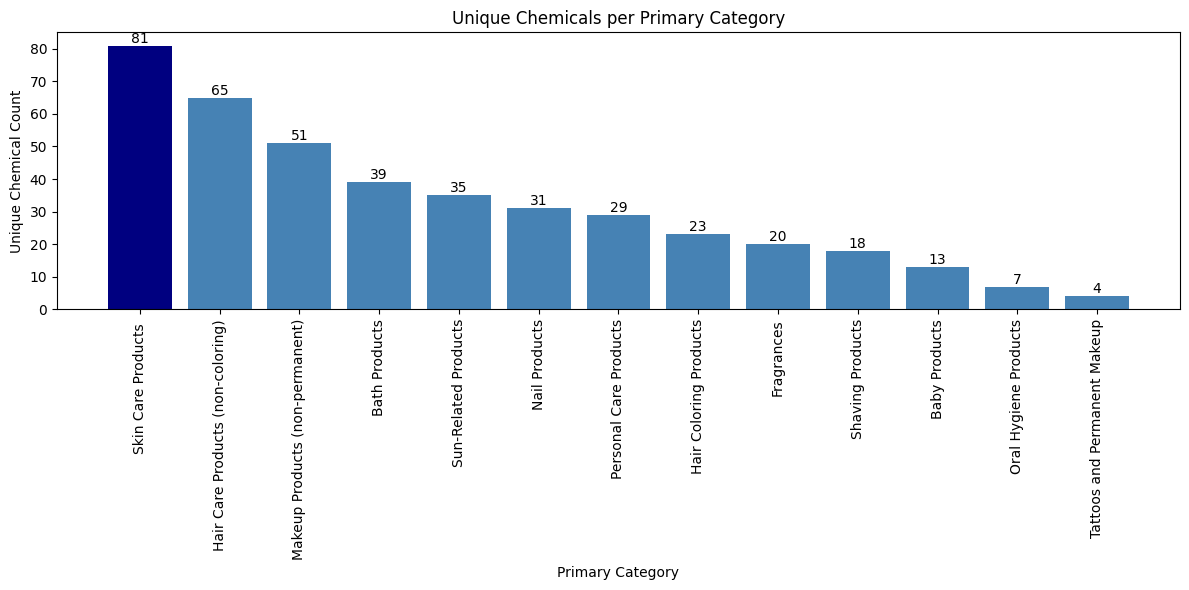

In [25]:
plt.figure(figsize=(12,6))

# Find the maximum value
max_value = no_unique_chem['UniqueChemicalCount'].max()

# Highlight max bar with darker color
colors = ['navy' if val == max_value else 'steelblue' 
          for val in no_unique_chem['UniqueChemicalCount']]

bars = plt.bar(no_unique_chem['PrimaryCategory'], 
               no_unique_chem['UniqueChemicalCount'], 
               color=colors)

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.xticks(rotation=90)
plt.xlabel('Primary Category')
plt.ylabel('Unique Chemical Count')
plt.title('Unique Chemicals per Primary Category')
plt.tight_layout()
plt.show()

2. Which chemicals appear most frequently across cosmetic products?

In [26]:
top_chemicals = data['ChemicalName'].value_counts().head(10)
top_chemicals

ChemicalName
Titanium dioxide                                                                                       31275
Silica, crystalline (airborne particles of respirable size)                                             1357
Cocamide diethanolamine                                                                                  804
Carbon black                                                                                             713
Mica                                                                                                     650
Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.      643
Talc                                                                                                     586
Retinyl palmitate                                                                                        508
Trade Secret                                                                                             404
Vitami

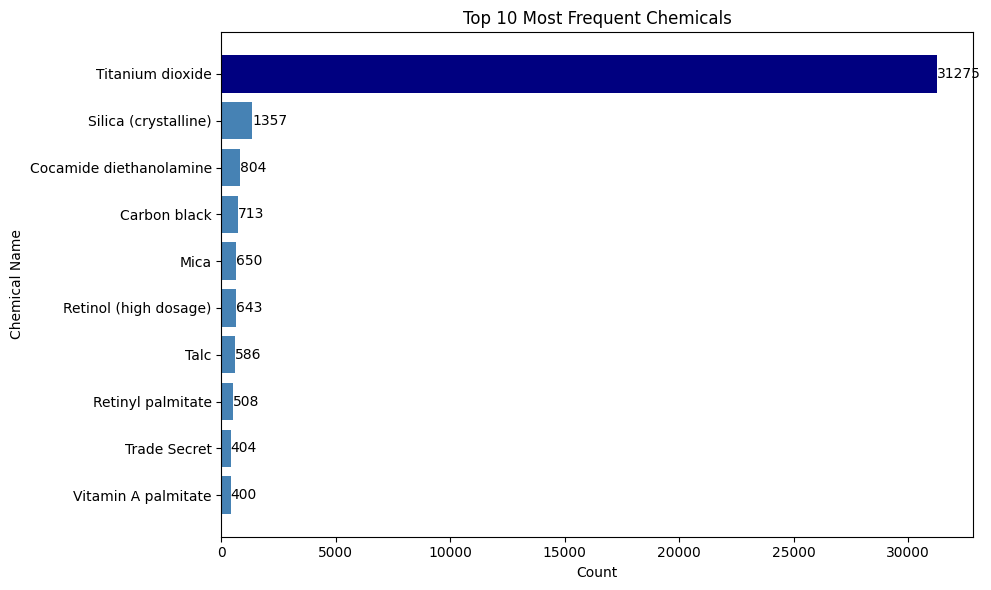

In [27]:
plt.figure(figsize=(10,6))

# Rename only specific long labels directly in the plot
labels = [
    "Silica (crystalline)" if x == "Silica, crystalline (airborne particles of respirable size)" 
    else "Retinol (high dosage)" if x == "Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents."
    else x
    for x in top_chemicals.index
]

# Get max value
max_value = top_chemicals.max()

# Colors
colors = ['navy' if val == max_value else 'steelblue' 
          for val in top_chemicals]

bars = plt.barh(labels, top_chemicals.values, color=colors)

# Add numbers
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', ha='left')

plt.xlabel('Count')
plt.ylabel('Chemical Name')
plt.title('Top 10 Most Frequent Chemicals')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

3. Which companies/brands use the widest variety of chemicals?

In [28]:
comp_chem_unique = data.groupby('CompanyName')['ChemicalId'].nunique().sort_values(ascending=False).head(10)
comp_chem_unique

CompanyName
Nail Alliance - Entity                 2098
American International Industries      1988
Revlon Consumer Product Corporation    1358
AMOREPACIFIC US INC.                   1089
Buth-na-Bodhaige, Inc                  1072
L'Oreal USA                            1053
Hand & Nail Harmony, Inc                957
S+                                      879
Coty                                    872
Anastasia Beverly Hills, LLC            851
Name: ChemicalId, dtype: int64

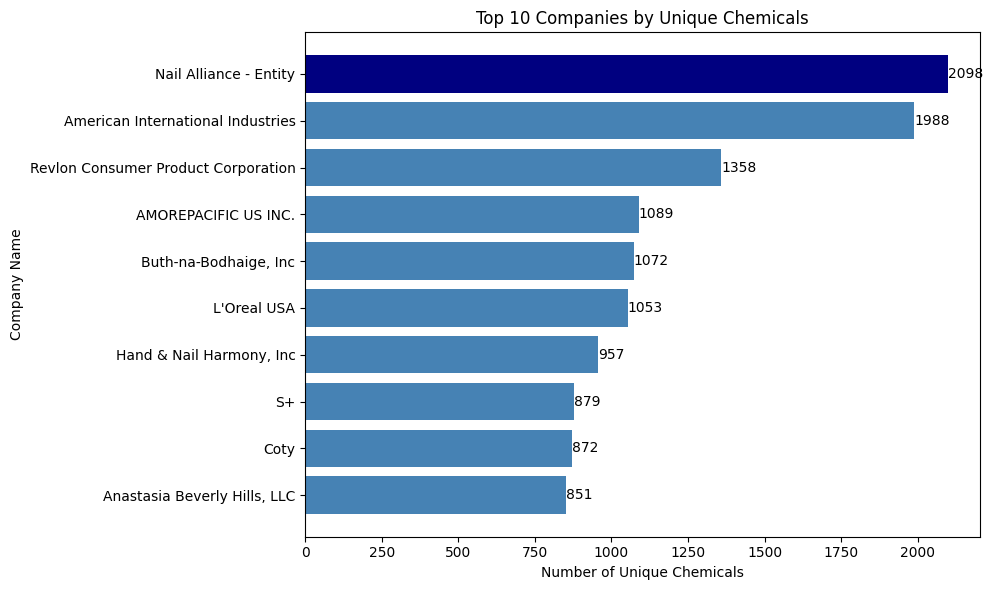

In [29]:
plt.figure(figsize=(10,6))

# Get max value
max_value = comp_chem_unique.max()

# Colors (highlight highest)
colors = ['navy' if val == max_value else 'steelblue' 
          for val in comp_chem_unique]

bars = plt.barh(comp_chem_unique.index, comp_chem_unique.values, color=colors)

# Add numbers at the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', ha='left')

plt.xlabel('Number of Unique Chemicals')
plt.ylabel('Company Name')
plt.title('Top 10 Companies by Unique Chemicals')

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

In [30]:
Brands_chem_unique = data.groupby('BrandName')['ChemicalId'].nunique().sort_values(ascending=False).head(10)
Brands_chem_unique 

BrandName
The Body Shop               1035
Gelish                       994
Revlon                       985
Entity                       851
Anastasia Beverly Hills      772
Artistic                     725
ZOEVA                        724
SEPHORA                      590
Victoria's Secret Beauty     524
AVON                         462
Name: ChemicalId, dtype: int64

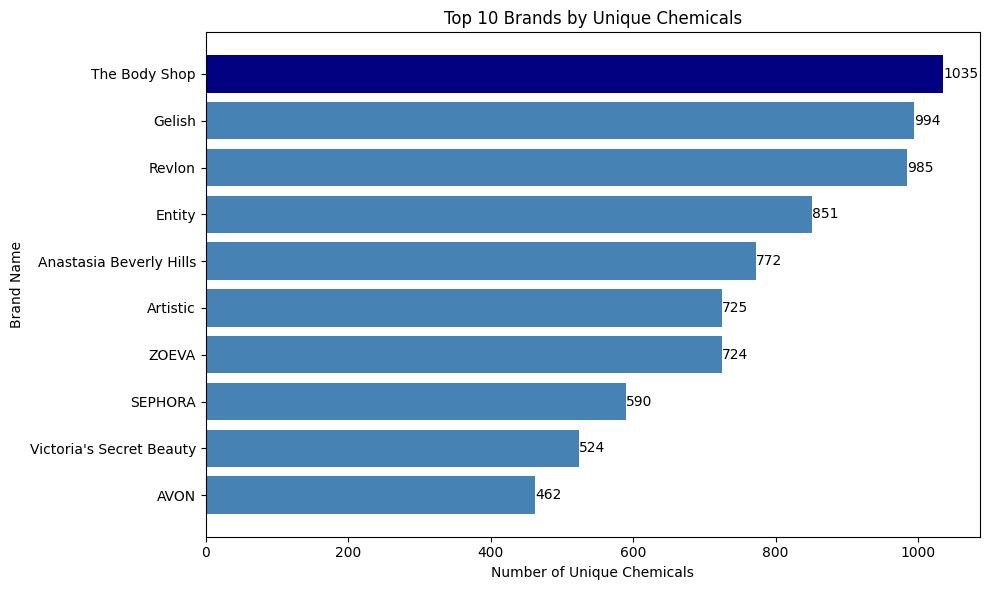

In [31]:
plt.figure(figsize=(10,6))

# Get max value
max_value = Brands_chem_unique.max()

# Colors (highlight highest)
colors = ['navy' if val == max_value else 'steelblue' 
          for val in Brands_chem_unique]

bars = plt.barh(Brands_chem_unique.index, Brands_chem_unique.values, color=colors)

# Add numbers at the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', ha='left')

plt.xlabel('Number of Unique Chemicals')
plt.ylabel('Brand Name')
plt.title('Top 10 Brands by Unique Chemicals')

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

4. How has the reporting of chemicals changed over the Years?

In [32]:
reported_chem_data = data[data['ChemicalCreatedAt'].notna()][['ChemicalCreatedAt']]
reported_chem_data

,ChemicalCreatedAt
0,2009-07-09
1,2009-07-01
2,2009-07-02
3,2009-07-09
4,2009-07-09
...,...
114622,2020-06-18
114623,2020-06-18
114626,2020-06-19
114630,2020-06-19


In [33]:
reported_chem_data['year'] = reported_chem_data['ChemicalCreatedAt'].dt.year
reported_chem_data

,ChemicalCreatedAt,year
0,2009-07-09,2009
1,2009-07-01,2009
2,2009-07-02,2009
3,2009-07-09,2009
4,2009-07-09,2009
...,...,...
114622,2020-06-18,2020
114623,2020-06-18,2020
114626,2020-06-19,2020
114630,2020-06-19,2020


In [34]:
chem_per_year = reported_chem_data.groupby('year').size()
chem_per_year

year
2009    8801
2010    5314
2011    1457
2012    1674
2013    2514
2014    2961
2015    2973
2016    2064
2017    3439
2018    3064
2019    5606
2020     910
dtype: int64

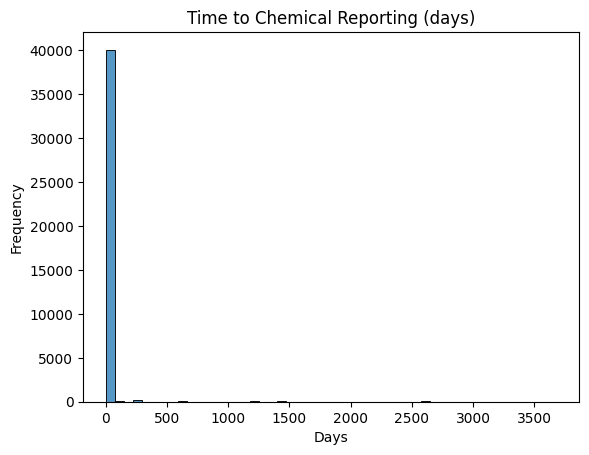

In [35]:
plt.figure()
sns.histplot(data['Time_to_Chemical_Report'].dropna(), bins=50)
plt.title('Time to Chemical Reporting (days)')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

In [36]:
reported_chem_data['ChemicalCreatedAt'].max()

#we dont have the full data for the year 2020 thats why the number of reported cases is significantlly lower in 2020 so we will exclude it in the visual analysis 

Timestamp('2020-06-23 00:00:00')

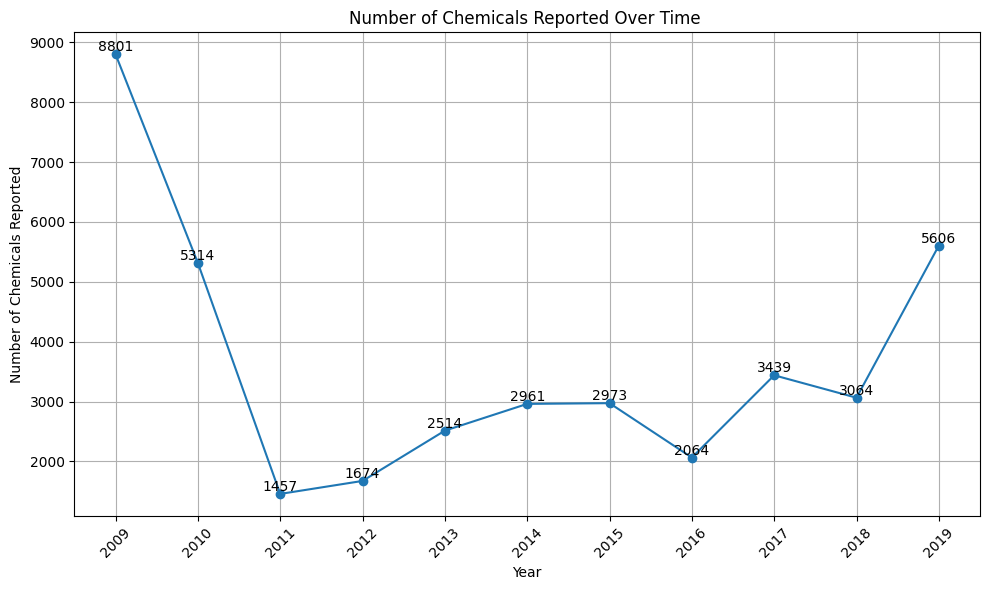

In [37]:
# Aggregate
chem_per_year = reported_chem_data.groupby('year').size().sort_index()

# Remove last year only for visualization
chem_per_year_plot = chem_per_year.iloc[:-1]

plt.figure(figsize=(10,6))

plt.plot(chem_per_year_plot.index, chem_per_year_plot.values, marker='o')

# Force all years to show
plt.xticks(chem_per_year_plot.index, rotation=45)

# Add labels
for x, y in zip(chem_per_year_plot.index, chem_per_year_plot.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.xlabel('Year')
plt.ylabel('Number of Chemicals Reported')
plt.title('Number of Chemicals Reported Over Time ')

plt.grid(True)
plt.tight_layout()
plt.show()

5. How have the number of reported chemicals, removed chemicals, and discontinued products changed over the years?

In [38]:
data_time= data[['ChemicalCreatedAt','ChemicalDateRemoved','DiscontinuedDate']].copy()
data_time

,ChemicalCreatedAt,ChemicalDateRemoved,DiscontinuedDate
0,2009-07-09,NaT,2011-02-01
1,2009-07-01,NaT,NaT
2,2009-07-02,NaT,NaT
3,2009-07-09,NaT,NaT
4,2009-07-09,NaT,2011-02-01
...,...,...,...
114622,2020-06-18,NaT,NaT
114623,2020-06-18,NaT,NaT
114626,2020-06-19,NaT,NaT
114630,2020-06-19,NaT,NaT


In [39]:
data_time['reported_year'] = data_time['ChemicalCreatedAt'].dt.year.astype('Int64')
data_time['removed_year'] = data_time['ChemicalDateRemoved'].dt.year.astype('Int64')
data_time['discountinued_year'] = data_time['DiscontinuedDate'].dt.year.astype('Int64')

In [40]:
reported = data_time['reported_year'].value_counts().sort_index()
removed = data_time['removed_year'].value_counts().sort_index()
discontinued = data_time['discountinued_year'].value_counts().sort_index()

In [41]:
trend_reporting = pd.DataFrame({'Reported' : reported ,
                               "Removed" : removed,
                               "Discontinued" : discontinued}).fillna(0)

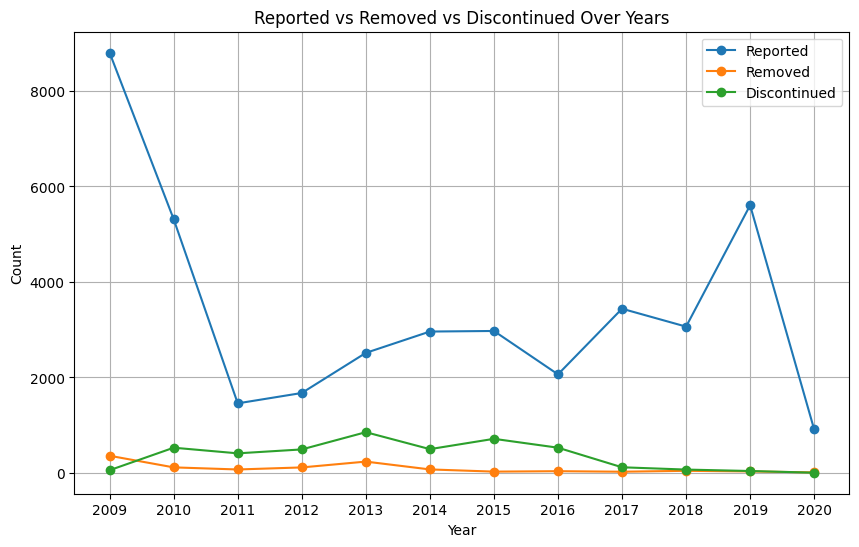

In [42]:
trend_reporting.plot(figsize=(10,6), marker='o')

plt.title('Reported vs Removed vs Discontinued Over Years')
plt.xlabel('Year')
plt.ylabel('Count')


plt.xticks(trend_reporting.index)

plt.grid(True)
plt.show()

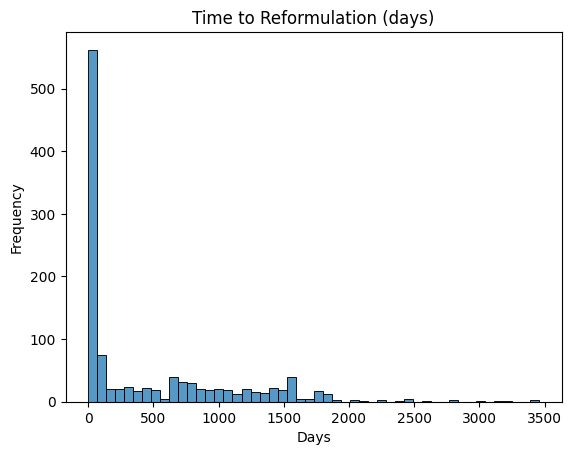

In [43]:
plt.figure()
sns.histplot(data['Time_to_Reformulation'].dropna(), bins=50)
plt.title('Time to Reformulation (days)')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

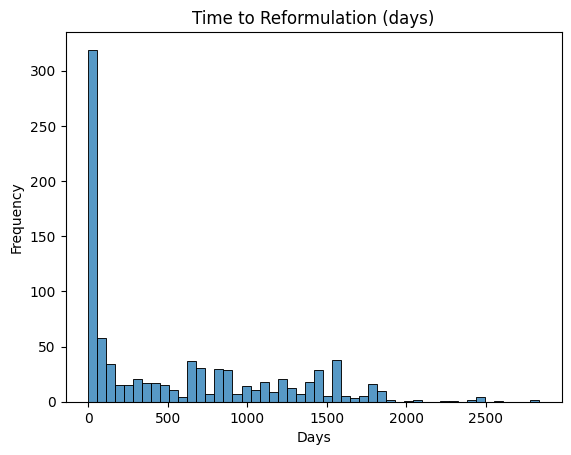

In [44]:
plt.figure()
dataforVis = data[(data['Time_to_Reformulation']>0) & (data['Time_to_Reformulation']<3000)]
sns.histplot(dataforVis['Time_to_Reformulation'].dropna(), bins=50)
# sns.histplot(data['Time_to_Reformulation'].dropna(), bins=50)
plt.title('Time to Reformulation (days)')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

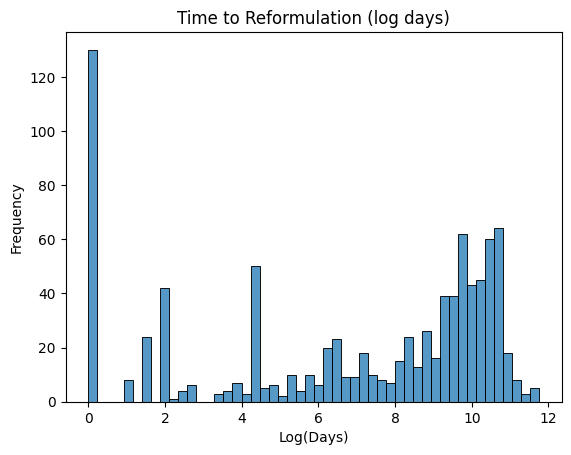

In [45]:
import numpy as np
plt.figure()
dataforVis = data[(data['Time_to_Reformulation']>0) & (data['Time_to_Reformulation']<5000)]
dataforVis['Log_Time_to_Reformulation'] = np.log2(dataforVis['Time_to_Reformulation'])
sns.histplot(dataforVis['Log_Time_to_Reformulation'].dropna(), bins=50)
# sns.histplot(data['Time_to_Reformulation'].dropna(), bins=50)
plt.title('Time to Reformulation (log days)')
plt.xlabel('Log(Days)')
plt.ylabel('Frequency')
plt.show()

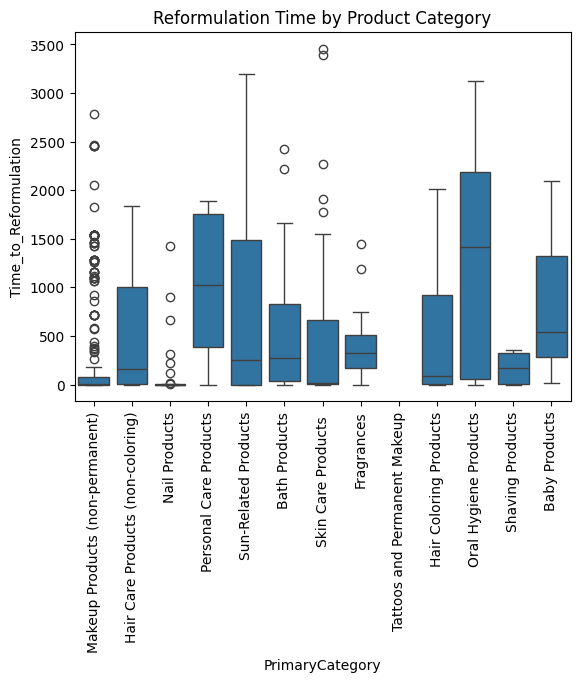

In [46]:
plt.figure()
sns.boxplot(
    data=data,
    x='PrimaryCategory',
    y='Time_to_Reformulation',
)
plt.xticks(rotation=90)
plt.title('Reformulation Time by Product Category')

plt.show()

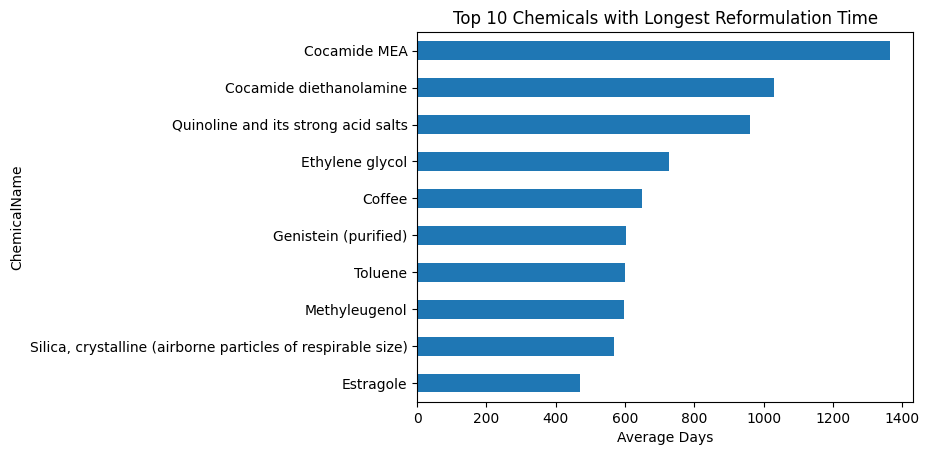

In [47]:
top_chemicals = (
    data.groupby('ChemicalName')['Time_to_Reformulation']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_chemicals.plot(kind='barh')
plt.title('Top 10 Chemicals with Longest Reformulation Time')
plt.xlabel('Average Days')
plt.gca().invert_yaxis()
plt.show()

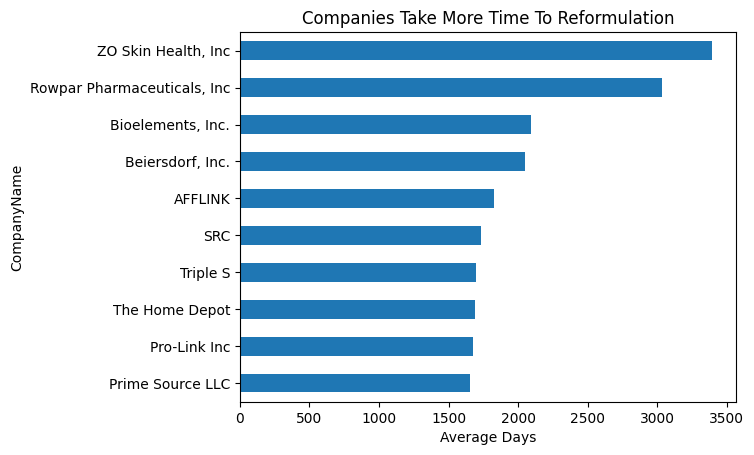

In [48]:
company_stats = (
    data.groupby('CompanyName')['Time_to_Reformulation']
    .mean()
    .sort_values()
    .dropna()
    .tail(10)
)

company_stats 
plt.figure()
company_stats.plot(kind='barh')
plt.title('Companies Take More Time To Reformulation')
plt.xlabel('Average Days')
plt.show()

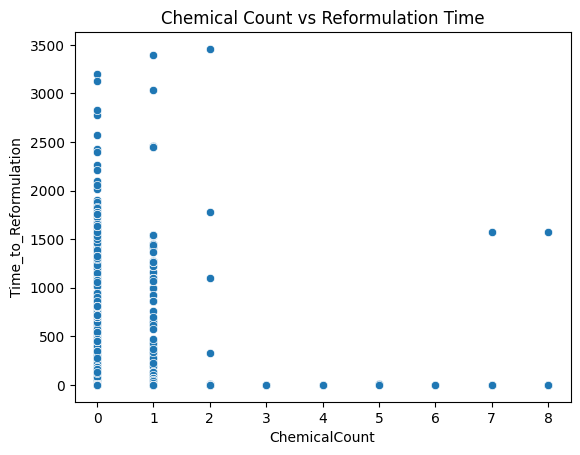

In [49]:
plt.figure()
sns.scatterplot(
    data=data,
    x='ChemicalCount',
    y='Time_to_Reformulation'
)
plt.title('Chemical Count vs Reformulation Time')
plt.show()

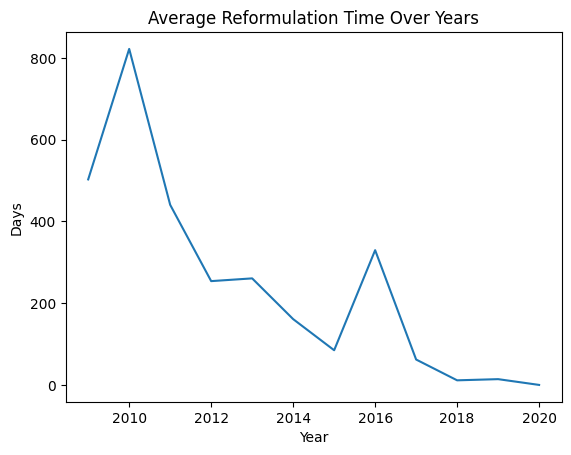

In [50]:
data['Year'] = data['ChemicalCreatedAt'].dt.year

yearly = data.groupby('Year')['Time_to_Reformulation'].mean()

plt.figure()
yearly.plot()
plt.title('Average Reformulation Time Over Years')
plt.xlabel('Year')
plt.ylabel('Days')
plt.show()

---

## Summary
__Summarizing the key insights from the analysis__

**Note**: 
* Skin care products contain the highest number of reported chemicals.
* The most frequently reported chemicals are titanium dioxide and silica.
* Revlon and The Body Shop have the highest number of unique chemicals.
* Most chemicals are removed from products relatively quickly after being reported.
* Nail products have the shortest reformulation time, while oral hygiene products have the longest.
* Cocamide shows the longest reformulation time, suggesting it may be underregulated or overlooked.
* ZO Skin Health, Inc. has the highest average reformulation time among companies.
* From 2009 to 2020, the average reformulation time has decreased.



## Recommendations/Conclusion
**Note**: 
* Cocamide, which exhibit long reformulation times, should be prioritized for regulatory review and monitoring, as prolonged presence may indicate delayed industry response or challenges in substitution.
* Skin care products should be subject to stricter formulation guidelines and transparency requirements, as they contain the highest number of reported chemicals and may pose greater cumulative exposure risks.
* While many chemicals are removed quickly, further investigation is needed to determine whether this reflects proactive safety measures or delayed initial reporting.
* The observed decrease in reformulation time suggests improved industry responsiveness; however, continued monitoring is necessary to ensure consistent compliance across all companies and chemical types.